# Task 1.1: Sampling Theorem

**Student Name:**  Haris Salii
**Country:**  Switzerland
**Semester term:**  HS26  


## Day 1: Data & Domain

### Use Case
*Focus: domain and application context*

> In the context of monitoring local solar energy potential, continuous-time signals generated by variations in incoming solar radiation are acquired and converted into digital form using a pyranometer and the automatic data acquisition system at the MeteoSwiss station Bern/Zollikofen in order to record solar irradiance as 10-minute mean values.  
> <mark>The resulting digital signals are analyzed by energy planners and photovoltaic system operators to assess 30–60-minute irradiance ramps relevant to short-term yield, battery, and grid-feed decisions; the 10-minute means can show their general course but cannot reveal variations within an individual 10-minute averaging window.</mark>  
> This use case is particularly relevant for Switzerland because solar irradiance varies with cloud cover, season, and location, which can affect the planning and operation of photovoltaic systems.

### Problem Statement
*Focus: technical vulnerability*

<span style="background-color: #eeeeee;">*Guidelines: Formulate a clear and technically precise problem statement. Explicitly refer to the signal or image processing task under investigation and identify the specific technical risk or limitation associated with it. Describe what may go wrong if an approach, method, or parameter is chosen or applied inadequately. Explain why this technical vulnerability is critical within your selected use case. Write your problem statement as a short, focused paragraph (1–3 sentences).*</span>

> This project addresses the problem of determining an appropriate sampling rate for solar irradiance signals within the context of monitoring local solar energy potential at the MeteoSwiss station Bern/Zollikofen in Switzerland. If the sampling rate is too low, aliasing and the loss of short-term irradiance variations may occur, leading to an inaccurate representation of the available solar energy. If the sampling rate is unnecessarily high, the resulting data volume increases storage and processing requirements without necessarily providing additional useful information.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

<span style="background-color: #eeeeee;">*Guidelines: Clearly state what you intend to understand or demonstrate in relation to your use case. Formulate your objective at a conceptual level without describing specific methods, algorithms, or implementation details. The objective should explain what aspect of signal or image behavior you aim to analyze and why this analysis is important for your application. Write your objective as a short, focused paragraph (1–2 sentences).*</span>

> The objective of this project is to investigate how the choice of sampling interval affects the monitoring of short-term changes in solar irradiance at the MeteoSwiss station Bern/Zollikofen. The goal is to understand when the measured signal still provides enough information for a reliable assessment of local solar energy availability.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

<span style="background-color: #eeeeee;">*Guidelines: Describe a representative one-dimensional signal or two-dimensional image suitable for your use case. Briefly explain its physical origin, how it is acquired, its unit of measurement, and the key characteristics relevant to your investigation. Specify the exact dataset name and repository or institution from which the data originate, and justify why this source is appropriate. Write 3-5 concise sentences.*</span>

> The selected one-dimensional signal represents global solar irradiance at the MeteoSwiss station Bern/Zollikofen. It is generated by incoming direct and diffuse solar radiation, measured using a radiation sensor, and expressed in watts per square metre (W/m²). The dataset contains 10-minute mean values for the complete year 2025 and captures daily, seasonal, and short-term variations caused by changing weather conditions. The data originate from the “Automatic Weather Stations Measurement Values” dataset provided by MeteoSwiss and are appropriate because they offer regularly sampled measurements from an official Swiss monitoring station.

<span style="background-color: #eeeeee;">*Guideline: Visualize a representative excerpt of your signal or a relevant region of your image. If the data are audio-based, additionally provide a playable audio segment. All visualizations must include clearly labeled axes and the correct units.*</span>

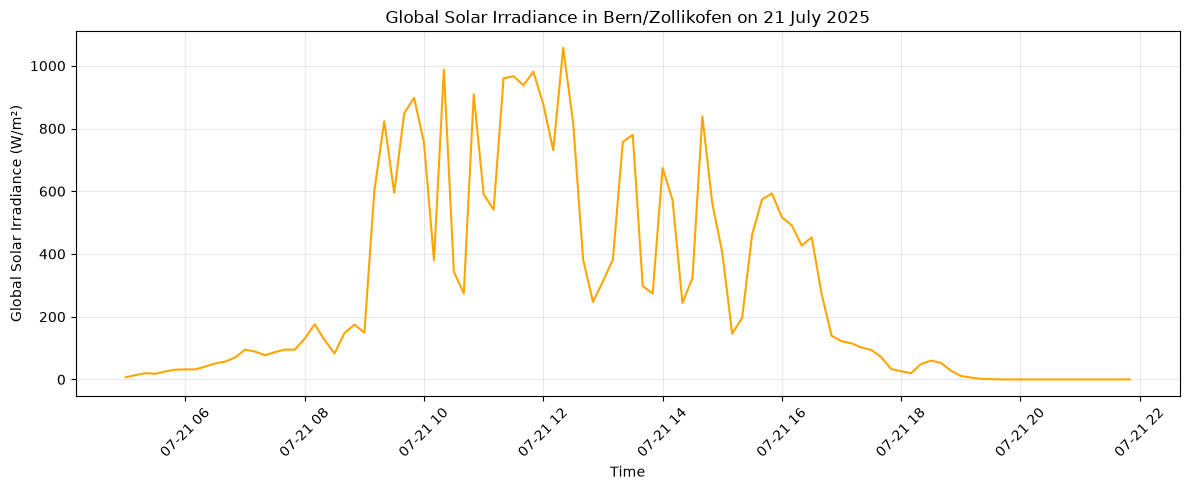

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/solarstrahlung_bern_2025.csv",
    sep=";"
)

data["time"] = pd.to_datetime(
    data["reference_timestamp"],
    dayfirst=True
)

selected_day = data[
    data["time"].dt.date == pd.Timestamp("2025-07-21").date()
]

selected_day = selected_day[
    selected_day["time"].dt.hour.between(5, 21)
]

plt.figure(figsize=(12, 5))
plt.plot(
    selected_day["time"],
    selected_day["gre000z0"],
    color="orange"
)

plt.title("Global Solar Irradiance in Bern/Zollikofen on 21 July 2025")
plt.xlabel("Time")
plt.ylabel("Global Solar Irradiance (W/m²)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations**:
The global solar irradiance increases from approximately 10 W/m² at 05:00 to more than 800 W/m² after 09:00. Between approximately 09:00 and 15:30, the signal shows several strong fluctuations and reaches a maximum of about 1,057 W/m² around midday. After 16:30, the measured irradiance decreases and approaches 0 W/m² after approximately 20:00.

**Interpretation of Nyquist Frequency and Nyquist Rate**

The available signal contains one 10-minute mean value every 10 minutes, corresponding to a sampling rate of six measurements per hour. The resulting Nyquist frequency is three cycles per hour, which corresponds to a shortest theoretical period of 20 minutes. Variations occurring faster than this limit cannot be represented reliably and may be averaged, missed, or affected by aliasing. In practice, an unnecessarily low sampling rate may hide relevant irradiance changes, while a very high sampling rate increases data volume and processing requirements.

## Day 2: Methodological Design

<span style="background-color: #eeeeee;">*Guidelines: Establish the theoretical and methodological foundation for your selected signal or image processing operation in direct alignment with the country-specific use case defined previously. Formally state the relevant theoretical principle and explain its assumptions, validity conditions, and domain-specific applicability. Select and justify concrete methods and parameter values appropriate for your one-dimensional signal or two-dimensional image data, explaining why these choices fit the defined analytical objective.
Derive necessary quantities mathematically where applicable, documenting each step with explicit assumptions and consistent units (temporal, spatial, or frequency units as relevant). Specify and justify the experimental design to be executed on the next day: define the parameters to vary, the control/baseline configuration, and the structured parameter sweep (ranges and step sizes). Theoretically predict the expected qualitative effects of these variations on the signal or image and identify likely failure modes (e.g., aliasing, instability, sensitivity to noise, loss of detail). Discuss methodological limitations, idealizations, and potential sources of misinterpretation. No simulations, visualizations, or experimental demonstrations should be included.*
</span>

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

<span style="background-color: #eeeeee;">*Guidelines: Establish the governing theoretical principle underlying your selected signal or image processing operation and briefly justify your chosen 1-2 method(s) in direct relation to your previously defined country-specific use case. State the key assumptions and validity conditions of the theory, and explain why the selected method appropriately operationalizes this principle for your data characteristics and analytical objective. Keep the explanation concise and technically precise. 2-4 sentences.*</span>

You may use the following structure as guidance:

> In dieser Untersuchung wird das Nyquist-Shannon-Abtasttheorem angewendet, um zu untersuchen, wie unterschiedliche Messintervalle die Erfassung von Solarstrahlungsschwankungen an der MeteoSwiss-Station Bern/Zollikofen beeinflussen. 

> Das Theorem setzt ein bandbegrenztes kontinuierliches Signal und eine gleichmässige Abtastung voraus. Für eine ideale Rekonstruktion muss die Abtastfrequenz mehr als doppelt so hoch sein wie die höchste enthaltene Signalfrequenz.

> <mark>Als Referenz wird eine kontrollierte Approximation aus den vorhandenen 10-Minuten-Werten erzeugt: Nach der Fourier-Transformation werden Frequenzanteile über 2 Zyklen/h entfernt; anschliessend wird die bandbegrenzte Folge durch Fourier-Resampling auf ein 1-Minuten-Raster übertragen.</mark>

> Bei einer zu niedrigen Abtastfrequenz kann Aliasing auftreten, wodurch schnelle Veränderungen der Solarstrahlung fälschlicherweise als langsamere Schwankungen erscheinen und relevante Informationen verloren gehen.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

<span style="background-color: #eeeeee;">*Guidelines: Define and justify relevant signal/image parameters and method-specific parameters required for your analysis. Clearly distinguish between data-inherent parameters (e.g., sampling frequency, spatial resolution, signal length, bandwidth) and method parameters (e.g., kernel size, lag range, cutoff frequency, window length). Derive necessary quantities mathematically where applicable and document each step with explicit assumptions and consistent physical units. Explicitly map abstract parameters to their physical meaning in your domain (e.g., lag in days, kernel width in meters or pixels). Parameter choices must be technically motivated and aligned with the defined use case. 2-4 sentences.*</span>

**Mathematische Herleitung**

Die ursprüngliche Abtastrate der MeteoSwiss-Daten beträgt:

$$
f_{s,\mathrm{original}} = \frac{60}{10} = 6\,\text{Messwerte/h}
$$

Daraus ergibt sich die Nyquist-Frequenz der vorhandenen Messreihe:

$$
f_{N,\mathrm{original}} = \frac{6}{2} = 3\,\text{Zyklen/h}
$$

Für die gewählte Modellbandbreite von 2 Zyklen pro Stunde ergibt sich folgende theoretische Nyquist-Rate:

$$
f_{s,\mathrm{Nyquist}} = 2 \cdot B_{\mathrm{model}} = 2 \cdot 2 = 4\,\text{Messwerte/h}
$$

Dies entspricht einem Messintervall von 15 Minuten. Für die ideale Rekonstruktion verwenden wir eine Abtastrate oberhalb dieser Grenze.

> Die MeteoSwiss-Messreihe der Station Bern/Zollikofen enthält zehnminütige Mittelwerte der Globalstrahlung in W/m². Daraus ergeben sich eine ursprüngliche Abtastrate von 6 Messwerten pro Stunde und eine Nyquist-Frequenz von 3 Zyklen pro Stunde.

> <mark>Für das experimentelle Referenzmodell wird eine Bandbreite von 2 Zyklen/h festgelegt, weil im Anwendungsfall Einstrahlungsänderungen mit Perioden ab 30 Minuten betrachtet werden. Der Wert liegt unter der Nyquist-Frequenz der vorhandenen Messreihe und ist eine inhaltlich gewählte Untersuchungsgrenze, keine nachgewiesene physikalische Bandbreite der realen Solarstrahlung.</mark>

> Die daraus abgeleitete Nyquist-Rate beträgt 4 Messwerte pro Stunde. Diese Parameter ermöglichen einen strukturierten Vergleich verschiedener Messintervalle, um den möglichen Verlust kurzfristiger Einstrahlungsschwankungen zu untersuchen.

### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*

<span style="background-color: #eeeeee;">*Guidelines: Specify the experimental setup to be implemented on the next days. Define the baseline configuration and identify the key 2-4 parameters that will be systematically varied. Describe the structured parameter sweep (ranges, step sizes, and controlled variables) and justify why these variations are meaningful for your signal or image and use case. Theoretically predict the expected qualitative effects of parameter changes. Ensure the setup is traceable and reproducible by clearly documenting fixed settings and variation logic. Theoretically predict the expected qualitative effects of these parameter changes on signal behavior, image structure, or system response. No simulations or results should be included. 2-4 sentences.*</span>

You may use the following structure as guidance:

> Als Ausgangskonfiguration dient eine hochauflösende, bandbegrenzte Approximation des ausgewählten MeteoSwiss-Tagesverlaufs vom 21. Juli 2025 mit einer Modellbandbreite von 2 Zyklen pro Stunde; die ursprüngliche zehnminütige Abtastung wird als Vergleichskonfiguration verwendet.

> Die Abtastrate wird systematisch durch drei Messintervalle variiert: 10 Minuten (6 Messwerte/h), 15 Minuten (4 Messwerte/h) und 30 Minuten (2 Messwerte/h), um die Bedingungen oberhalb, genau an und unterhalb der Nyquist-Rate abzudecken.

> Der Untersuchungszeitraum, das Referenzsignal, die Modellbandbreite und die zeitliche Ausrichtung bleiben dabei unverändert, sodass Unterschiede auf die gewählte Abtastrate zurückgeführt werden können.

> <mark>Theoretisch wird erwartet, dass Signalanteile unterhalb der jeweiligen Nyquist-Frequenz eindeutig erfasst werden können. Bei 10 Minuten liegt die Abtastrate über der Grenzrate, bei 15 Minuten genau daran und bei 30 Minuten darunter; daher werden am Grenzwert phasenabhängige Probleme und bei 30 Minuten Aliasing beziehungsweise Informationsverlust erwartet.</mark>

### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

<span style="background-color: #eeeeee;">*Guidelines: Identify the main methodological 1-3 limitations of your theoretical model, method selection, and parameterization. Explicitly state idealized assumptions and discuss how real-world signal or image characteristics may violate them (e.g., noise, non-linearity, non-stationarity, boundary effects, model mismatch, limited resolution). Analyze under which conditions the method remains stable and valid, and under which conditions it may become unreliable or misleading in your use case. 1-3 sentences.*</span>

You may use the following structure as guidance:

> Das Nyquist-Shannon-Abtasttheorem setzt ein bandbegrenztes Signal und eine gleichmässige Abtastung voraus; bei den realen MeteoSwiss-Daten können jedoch schnelle Einstrahlungsschwankungen durch die zehnminütige Mittelwertbildung bereits abgeschwächt oder verloren gegangen sein.

> Die festgelegte Modellbandbreite von 2 Zyklen pro Stunde stellt deshalb eine experimentelle Annahme dar, während die tatsächliche physikalische Bandbreite der Solarstrahlung unbekannt bleibt.

> Die Untersuchung erlaubt unter kontrollierten Modellbedingungen einen nachvollziehbaren Vergleich verschiedener Abtastraten, ihre Ergebnisse dürfen jedoch aufgrund möglicher schneller Wolkenwechsel, Messrauschen und Modellabweichungen nicht als exakte Rekonstruktion der ursprünglichen Solarstrahlung interpretiert werden.

## Day 3: Implementation

*Focus: structured, traceable execution*



### 1. Hochauflösende Referenz erzeugen

Zuerst werden die bereits ausgewählten MeteoSwiss-Daten vom 21. Juli 2025 verwendet.  
Aus diesen 10-Minuten-Mittelwerten wird eine kontrollierte, bandbegrenzte Referenz erzeugt, die später als Vergleich für verschiedene Abtastraten dient.
Gemäss Day 2 wird die maximale Modellfrequenz auf 2 Zyklen pro Stunde begrenzt.  
Die Referenz wird anschliessend auf einem 1-Minuten-Zeitraster dargestellt.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample

data = pd.read_csv(
    "../data/solarstrahlung_bern_2025.csv",
    sep=";"
)

data["time"] = pd.to_datetime(
    data["reference_timestamp"],
    dayfirst=True
)

selected_day = data[
    data["time"].dt.date == pd.Timestamp("2025-07-21").date()
].copy()

selected_day = selected_day[
    selected_day["time"].dt.hour.between(5, 21)
].copy()

time = selected_day["time"].reset_index(drop=True)
irradiance = selected_day["gre000z0"].to_numpy()

### Bandbegrenzung der Referenz

Gemäss Day 2 wird die maximale Modellfrequenz auf 2 Zyklen pro Stunde begrenzt.

Dazu wird das ausgewählte Solarstrahlungssignal in den Frequenzbereich transformiert, Frequenzanteile oberhalb dieser Grenze werden entfernt und das Signal anschliessend wieder in den Zeitbereich zurücktransformiert.

In [66]:
irradiance = selected_day["gre000z0"].to_numpy()

sampling_rate = 6
bandwidth = 2

spectrum = np.fft.rfft(irradiance)

frequencies = np.fft.rfftfreq(
    len(irradiance),
    d=1 / sampling_rate
)

spectrum[frequencies > bandwidth] = 0

bandlimited_signal = np.fft.irfft(
    spectrum,
    n=len(irradiance)
)

### Hochauflösendes Zeitraster

Die bandbegrenzte Approximation liegt zunächst weiterhin an den ursprünglichen 10-Minuten-Zeitpunkten vor.

<mark>Für das 1-Minuten-Raster verwende ich Fourier-Resampling. Dabei wird das bereits begrenzte Spektrum mit Nullen ergänzt und danach wieder in den Zeitbereich zurückgeführt. So bleibt die festgelegte Bandgrenze erhalten. Das feinere Raster ist weiterhin nur eine Modellreferenz und enthält keine zusätzlichen Messwerte.</mark>


In [67]:
upsampling_factor = 10
reference_length = len(bandlimited_signal) * upsampling_factor

reference_signal = resample(
    bandlimited_signal,
    reference_length
)
reference_minutes = np.arange(reference_length)

# Kontrolle: Bandgrenze und Übereinstimmung an den ursprünglichen Punkten
reference_frequencies = np.fft.rfftfreq(
    reference_length,
    d=1 / 60
)
reference_spectrum = np.fft.rfft(reference_signal)

total_spectral_energy = np.sum(np.abs(reference_spectrum) ** 2)
out_of_band_energy = np.sum(
    np.abs(reference_spectrum[reference_frequencies > bandwidth]) ** 2
)
out_of_band_share = 100 * out_of_band_energy / total_spectral_energy
sample_point_error = np.max(
    np.abs(reference_signal[::10] - bandlimited_signal)
)

print(f"Spektralenergie oberhalb 2 Zyklen/h: {out_of_band_share:.3e} %")
print(f"Max. Abweichung an 10-Minuten-Punkten: {sample_point_error:.3e} W/m²")

Spektralenergie oberhalb 2 Zyklen/h: 5.814e-30 %
Max. Abweichung an 10-Minuten-Punkten: 3.411e-13 W/m²


### Darstellung der Referenz

Die folgende Darstellung zeigt die erzeugte hochauflösende Referenzapproximation der Globalstrahlung.

Sie dient im nächsten Schritt als gemeinsames Ausgangssignal für die Abtastung oberhalb, genau an und unterhalb der Nyquist-Rate.

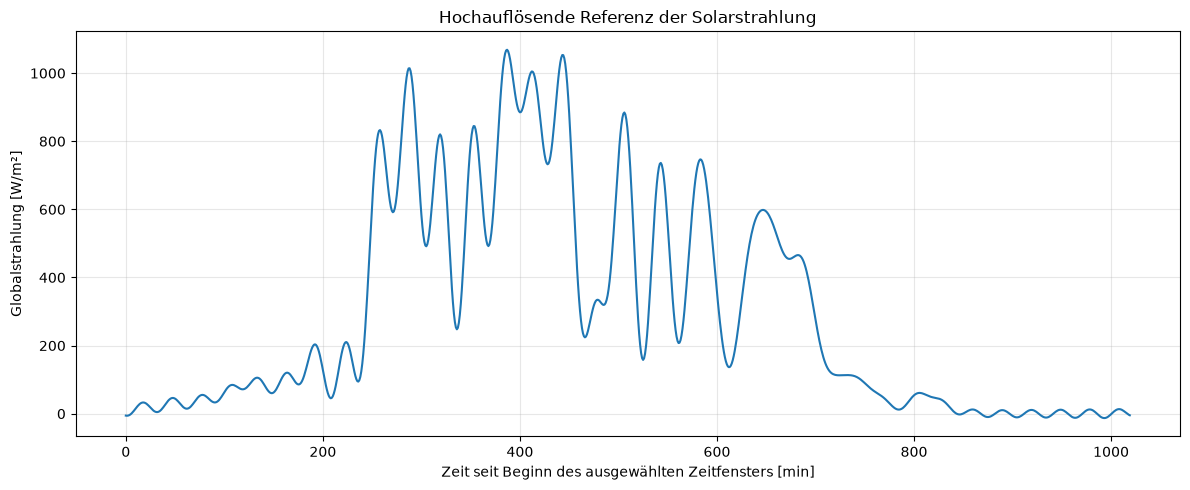

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    reference_minutes,
    reference_signal
)

plt.title("Hochauflösende Referenz der Solarstrahlung")
plt.xlabel("Zeit seit Beginn des ausgewählten Zeitfensters [min]")
plt.ylabel("Globalstrahlung [W/m²]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Sampling oberhalb, an und unter der Nyquist-Rate

Die hochauflösende Referenz wird nun mit drei unterschiedlichen Messintervallen abgetastet.

Verwendet werden 10 Minuten als Fall oberhalb der Nyquist-Rate, 15 Minuten als Grenzfall und 30 Minuten als Fall unterhalb der Nyquist-Rate.

In [69]:
sample_10 = reference_signal[::10]
time_10 = reference_minutes[::10]

sample_15 = reference_signal[::15]
time_15 = reference_minutes[::15]

sample_30 = reference_signal[::30]
time_30 = reference_minutes[::30]

### Vergleich der drei Sampling-Konfigurationen

Die folgende Darstellung zeigt dieselbe Referenz zusammen mit den drei unterschiedlichen Abtastungen.

Dadurch wird sichtbar, wie stark sich die Darstellung des Signals verändert, wenn die Abtastrate reduziert wird.

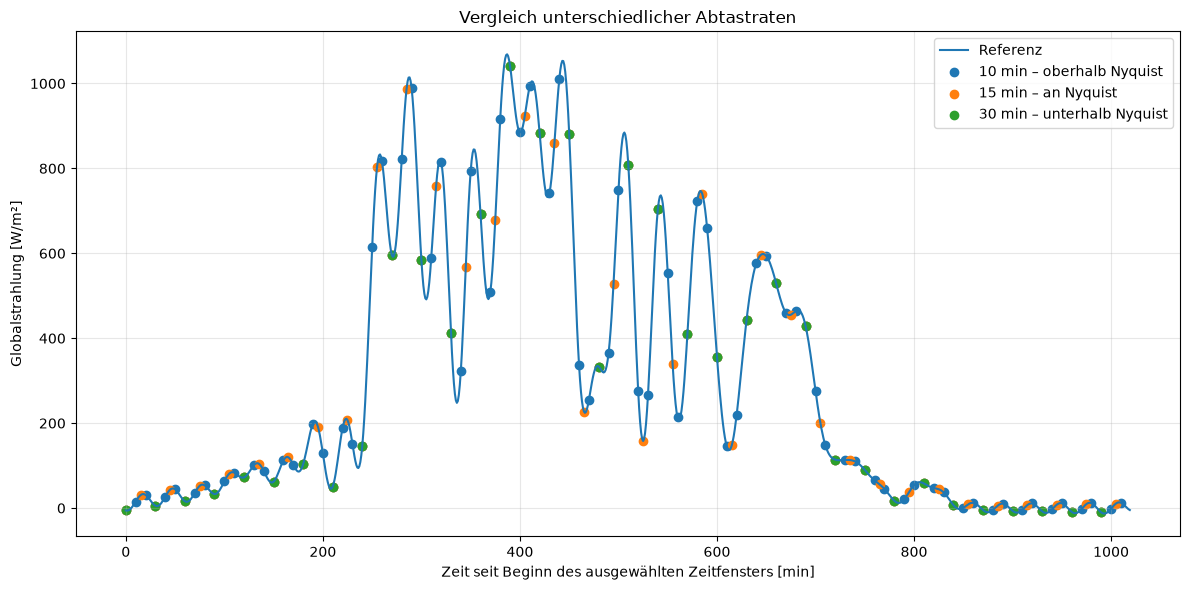

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    reference_minutes,
    reference_signal,
    label="Referenz"
)

plt.scatter(
    time_10,
    sample_10,
    label="10 min – oberhalb Nyquist"
)

plt.scatter(
    time_15,
    sample_15,
    label="15 min – an Nyquist"
)

plt.scatter(
    time_30,
    sample_30,
    label="30 min – unterhalb Nyquist"
)

plt.title("Vergleich unterschiedlicher Abtastraten")
plt.xlabel("Zeit seit Beginn des ausgewählten Zeitfensters [min]")
plt.ylabel("Globalstrahlung [W/m²]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Darstellung des undersampled Falls

Der 30-Minuten-Fall liegt unterhalb der Nyquist-Rate des Referenzmodells.

Zur Veranschaulichung wird die grob abgetastete Messreihe mit einer einfachen Verbindung der Messpunkte dargestellt und mit der hochauflösenden Referenz verglichen. Dadurch wird sichtbar, dass schnelle Signaländerungen zwischen den Messpunkten nicht mehr zuverlässig erfasst werden.

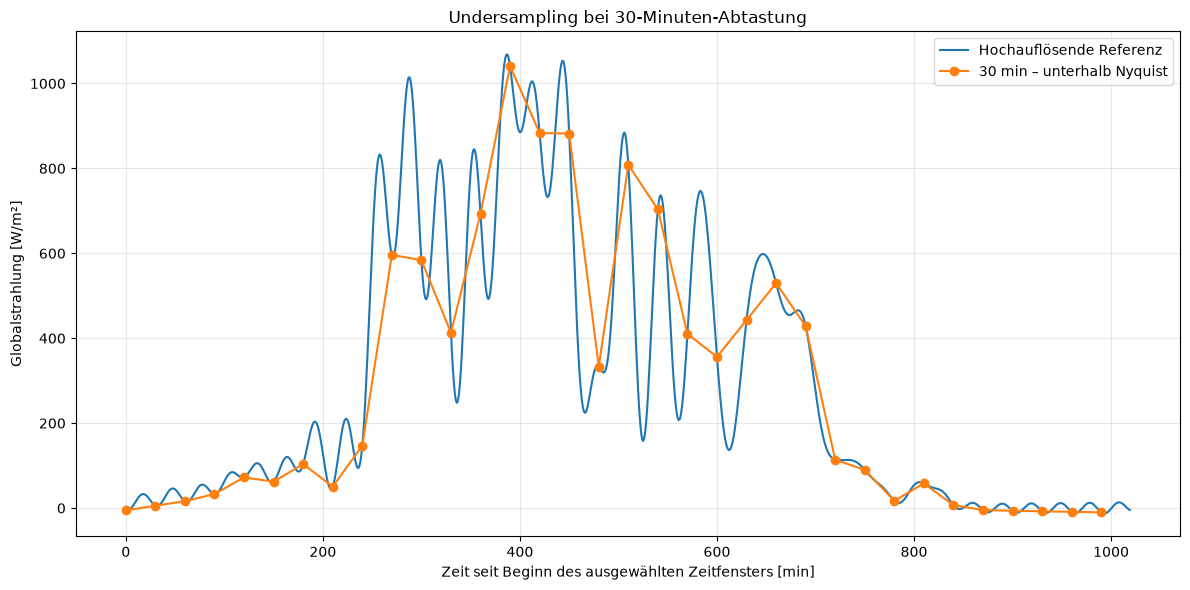

In [71]:
plt.figure(figsize=(12, 6))

plt.plot(
    reference_minutes,
    reference_signal,
    label="Hochauflösende Referenz"
)

plt.plot(
    time_30,
    sample_30,
    marker="o",
    label="30 min – unterhalb Nyquist"
)

plt.title("Undersampling bei 30-Minuten-Abtastung")
plt.xlabel("Zeit seit Beginn des ausgewählten Zeitfensters [min]")
plt.ylabel("Globalstrahlung [W/m²]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Kontrollierte Demonstration von Aliasing

Im Solarstrahlungssignal ist Aliasing im Frequenzbereich nicht eindeutig sichtbar. Deshalb wird ergänzend eine einzelne kontrollierte Frequenzkomponente innerhalb der in Day 2 festgelegten Modellbandbreite verwendet.

Die Testfrequenz beträgt 1.8 Zyklen pro Stunde. Bei einer 30-Minuten-Abtastung beträgt die Abtastrate 2 Messwerte pro Stunde und die Nyquist-Frequenz nur 1 Zyklus pro Stunde. Die Testfrequenz liegt somit oberhalb dieser Grenze und wird durch Aliasing als niedrigere Frequenz dargestellt.

Dieser Zusatzversuch dient ausschliesslich der technischen Demonstration von Aliasing und verändert die eigentliche MeteoSwiss-Analyse nicht.

In [72]:
test_frequency = 1.8
sampling_rate_30 = 2

alias_frequency = abs(test_frequency - sampling_rate_30)

test_time = np.arange(0, 5, 1 / 60)
sample_time = np.arange(0, 5, 0.5)

test_signal = np.cos(
    2 * np.pi * test_frequency * test_time
)

sampled_signal = np.cos(
    2 * np.pi * test_frequency * sample_time
)

alias_signal = np.cos(
    2 * np.pi * alias_frequency * test_time
)

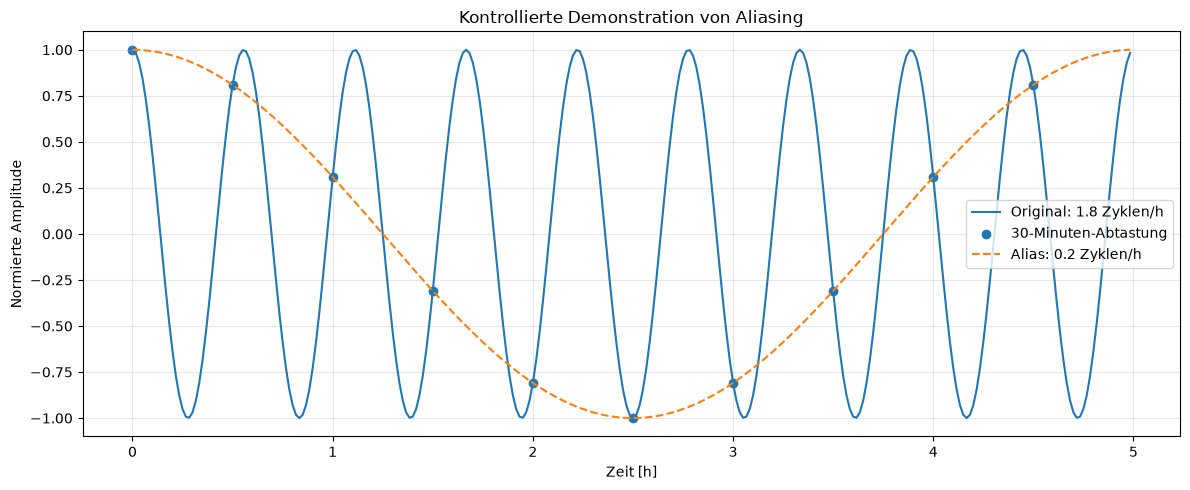

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_time,
    test_signal,
    label="Original: 1.8 Zyklen/h"
)

plt.scatter(
    sample_time,
    sampled_signal,
    label="30-Minuten-Abtastung"
)

plt.plot(
    test_time,
    alias_signal,
    linestyle="--",
    label="Alias: 0.2 Zyklen/h"
)

plt.title("Kontrollierte Demonstration von Aliasing")
plt.xlabel("Zeit [h]")
plt.ylabel("Normierte Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Die 30-Minuten-Abtastung kann die ursprüngliche Frequenz von 1.8 Zyklen/h nicht eindeutig erfassen. Die Abtastpunkte stimmen gleichzeitig mit einem langsameren Signal von 0.2 Zyklen/h überein.

Dies demonstriert Aliasing: Eine zu niedrige Abtastrate kann eine hohe Frequenz fälschlicherweise als niedrigere Frequenz erscheinen lassen.

## Day 4: Evaluation

### Evaluation Approach Definition

#### Metric-Based Evaluation

<mark>Als Bewertungsgrösse verwende ich weiterhin den Root Mean Squared Error (RMSE). Jede Sampling-Konfiguration wird mit demselben Fourier-Verfahren auf das gemeinsame 1-Minuten-Raster rekonstruiert und danach mit der bandbegrenzten Referenz verglichen. Der RMSE wird in W/m² angegeben und gewichtet grössere Abweichungen stärker. Das passt zum Anwendungsfall, weil grosse Fehler die kurzfristige Schätzung der PV-Leistung besonders stark beeinflussen können. Zusätzlich zeigt der NRMSE, wie gross der Fehler im Verhältnis zur Spannweite des Tagesverlaufs ist.</mark>

<mark>Der praktisch null grosse Fehler bei 10 Minuten ist nur eine interne Kontrolle. Er entsteht, weil die Referenz aus denselben 10-Minuten-Werten aufgebaut wurde, und beweist deshalb nicht, dass reale 10-Minuten-Mittelwerte alle relevanten Schwankungen erfassen.</mark>

### Evaluation Comparison Execution


Parameter Evaluation (Metric-Based)

<mark>Für alle drei Varianten verwende ich dasselbe modellierte Zeitfenster von 1'020 Minuten, dieselbe Fourier-Rekonstruktion und dieselbe Fehlerberechnung. Verändert wird nur das Messintervall. Dadurch können die Ergebnisse direkt miteinander verglichen werden.</mark>

In [74]:
configurations = {
    "10 min – oberhalb Nyquist": (sample_10, 10),
    "15 min – an Nyquist": (sample_15, 15),
    "30 min – unterhalb Nyquist": (sample_30, 30)
}

evaluation_rows = []
reconstructed_signals = {}
reference_range = np.ptp(reference_signal)

for name, (sample_values, interval) in configurations.items():
    reconstructed_signal = resample(
        sample_values,
        len(reference_signal)
    )
    reconstructed_signals[name] = reconstructed_signal

    rmse = np.sqrt(
        np.mean((reference_signal - reconstructed_signal) ** 2)
    )
    nrmse = 100 * rmse / reference_range

    evaluation_rows.append({
        "Konfiguration": name,
        "Abtastrate [Messwerte/h]": 60 / interval,
        "Messintervall [min]": interval,
        "RMSE [W/m²]": rmse,
        "NRMSE [% der Spannweite]": nrmse
    })

evaluation_results = pd.DataFrame(evaluation_rows)
evaluation_results.round(2)

,Konfiguration,Abtastrate [Messwerte/h],Messintervall [min],RMSE [W/m²],NRMSE [% der Spannweite]
0,10 min – oberhalb Nyquist,6.0,10,0.00,0.00
1,15 min – an Nyquist,4.0,15,20.76,1.92
2,30 min – unterhalb Nyquist,2.0,30,144.75,13.38


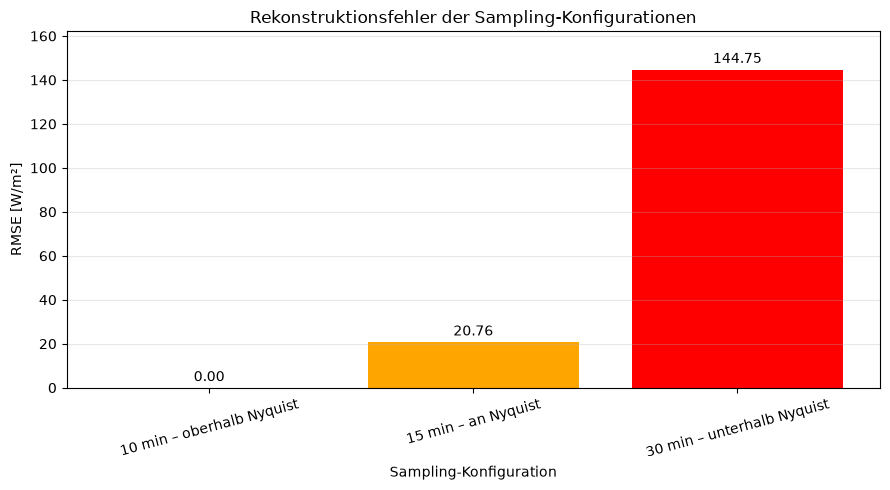

In [75]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    evaluation_results["Konfiguration"],
    evaluation_results["RMSE [W/m²]"],
    color=["green", "orange", "red"]
)

plt.title("Rekonstruktionsfehler der Sampling-Konfigurationen")
plt.xlabel("Sampling-Konfiguration")
plt.ylabel("RMSE [W/m²]")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, evaluation_results["RMSE [W/m²]"].max() * 1.12)

for bar, value in zip(
    bars,
    evaluation_results["RMSE [W/m²]"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Ergebnisse der RMSE-Auswertung

| Konfiguration | Abtastrate [Messwerte/h] | Messintervall [min] | RMSE [W/m²] | NRMSE [%] |
|:--|--:|--:|--:|--:|
| 10 min oberhalb Nyquist | 6 | 10 | <mark>0,00</mark> | <mark>0,00</mark> |
| 15 min an Nyquist | 4 | 15 | <mark>20,76</mark> | <mark>1,92</mark> |
| 30 min unterhalb Nyquist | 2 | 30 | <mark>144,75</mark> | <mark>13,38</mark> |

<mark>Bei 10 Minuten wird das Referenzsignal bis auf numerische Rundung reproduziert. Bei 15 Minuten beträgt der RMSE 20,76 W/m². Dieser Fall liegt genau an der Nyquist-Grenze und hängt deshalb von der Phase ab. Bei 30 Minuten steigt der RMSE auf 144,75 W/m² beziehungsweise 13,38 % der Referenzspannweite. Der Fehler ist damit rund 6,97-mal so gross wie bei 15 Minuten.</mark>

## Day 5: Analysis & Communication

### Observations


<mark>Der RMSE beträgt bei 10 Minuten 0,00 W/m², bei 15 Minuten 20,76 W/m² und bei 30 Minuten 144,75 W/m². Der Fehler der 30-Minuten-Abtastung ist damit rund 6,97-mal grösser als bei 15 Minuten. Der NRMSE steigt von 1,92 % auf 13,38 %.</mark>

### Interpretation 


<mark>Im Modell erfasst die 10-Minuten-Abtastung alle zugelassenen Frequenzen bis 2 Zyklen/h. Bei 15 Minuten liegt die höchste Modellfrequenz genau an der Nyquist-Grenze. Deshalb hängt die Rekonstruktion von der Phase ab und weicht bereits von der Referenz ab. Bei 30 Minuten liegen Frequenzanteile über der Nyquist-Frequenz von 1 Zyklus/h. Diese Anteile gehen verloren oder erscheinen als langsamere Verläufe. Dadurch können Zeitpunkt und Stärke von Einstrahlungsänderungen falsch eingeschätzt werden.</mark>


### Discussion and Critical Reflection

<mark>Im untersuchten Modell liefert das 10-Minuten-Intervall das genaueste Ergebnis. Daraus kann ich aber nicht ableiten, dass 10-Minuten-Mittelwerte für reale Solarstrahlung immer ausreichen. Der Fehler ist hier null, weil die Referenz aus genau diesen Ausgangswerten aufgebaut wurde. Ausserdem beschränkt die gewählte Bandbreite von 2 Zyklen/h die Untersuchung auf Veränderungen mit Perioden ab 30 Minuten. Schnellere Änderungen durch Wolken sind in den Ausgangsdaten möglicherweise bereits geglättet. Der RMSE zeigt den Gesamtfehler gut, kann aber kurze starke Abweichungen verdecken. Für eine zuverlässige Empfehlung wären unabhängige Messwerte im Sekunden- oder Minutenbereich nötig. Diese könnten anschliessend auf 10, 15 und 30 Minuten reduziert und mit der ursprünglichen hochauflösenden Messreihe verglichen werden.</mark>


## Day 15 

### Final Reflections on MC
>Overall, the most successful aspect of MC1 was ____________, particularly in relation to ____________ within the defined use case. The implementation of ____________ worked well because ____________, leading to ____________.
If repeating this work, I would reconsider ____________ or refine ____________, as this could improve ____________ and reduce ____________. Certain challenges emerged during ____________, highlighting the importance of ____________ in practical signal/image analysis.
I was particularly impressed by ____________, especially how ____________ influenced ____________ in the context of the application.
Through this project, I learned that ____________, and I developed a clearer understanding of ____________, especially regarding the connection between theoretical principles and real-world constraints.

### Revisions
- <mark>Der Anwendungsfall wurde auf relevante Einstrahlungsänderungen konkretisiert.</mark>
- <mark>Die Wahl von 2 Zyklen/h wurde begründet und die Aussage zur Nyquist-Grenze korrigiert.</mark>
- <mark>Die lineare Interpolation wurde durch Fourier-Resampling ersetzt.</mark>
- <mark>RMSE und NRMSE wurden neu berechnet und die Schlussfolgerung entsprechend angepasst.</mark>

### Sources and Tools

- Data source: MeteoSwiss, “Automatic Weather Stations Measurement Values,” parameter `gre000z0`, station Bern/Zollikofen.  
  https://opendatadocs.meteoswiss.ch/de/a-data-groundbased/a1-automatic-weather-stations
- Tools: Python 3, pandas, Matplotlib and <mark>SciPy (`scipy.signal.resample`)</mark>.
- OpenAI ChatGPT/Codex was used for language correction and general feedback on the notebook.